<a href="https://colab.research.google.com/github/HARRY-hussein/computer_vision/blob/main/SkyVision_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
print("First Detector Project")

First Detector Project


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

# Base project directory on your Google Drive
BASE_DIR = '/content/drive/MyDrive/weather_classifier'
DATASET_DIR = os.path.join(BASE_DIR, 'dataset_raw')
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)

print(f"Project folder: {BASE_DIR}")
print(f"Dataset folder: {DATASET_DIR}")

Project folder: /content/drive/MyDrive/weather_classifier
Dataset folder: /content/drive/MyDrive/weather_classifier/dataset_raw


In [31]:
import os
import json
from google.colab import files

# Upload kaggle.json from your computer
uploaded = files.upload()  # select your kaggle.json file

# Save it to the right place
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(json.loads(list(uploaded.values())[0]), f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle API key installed.")

Saving kaggle.json to kaggle (1).json
Kaggle API key installed.


In [32]:
# follow-up INSTRUCTIONS:
#    KAGGLE_USERNAME = "your_kaggle_username"
#    KAGGLE_KEY      = "your_kaggle_key"
#    (Get it from kaggle.com → Settings → API Tokens → Create New Token)
# 3. Click Runtime → Run all

import os, json, zipfile

# ============================================
# NEWCOMERS: faqat shu ikki qatorni o'zgartiring
KAGGLE_USERNAME = "bu_yerga_username_yozing"
KAGGLE_KEY      = "bu_yerga_key_yozing"
# ============================================

# Kaggle sozlash (o'zgartirish shart emas)
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print(f"Kaggle sozlandi: {KAGGLE_USERNAME}")

# Drive ulash
from google.colab import drive
drive.mount('/content/drive')

# Papkalar
BASE_DIR    = '/content/drive/MyDrive/weather_classifier'
DATASET_DIR = os.path.join(BASE_DIR, 'dataset_raw')
SPLIT_DIR   = os.path.join(BASE_DIR, 'dataset_split')
os.makedirs(DATASET_DIR, exist_ok=True)

# Dataset yuklash
print("Dataset yuklanmoqda...")
!kaggle datasets download -d pratik2901/multiclass-weather-dataset -p /content/weather_tmp --force

zip_path = '/content/weather_tmp/multiclass-weather-dataset.zip'
if not os.path.exists(zip_path):
    raise FileNotFoundError("Download muvaffaqiyatsiz — username va key ni tekshiring.")

print("Unzipping...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(DATASET_DIR)

print("Dataset tayyor!")

Kaggle sozlandi: bu_yerga_username_yozing
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset yuklanmoqda...
Dataset URL: https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 91.4M/91.4M [00:05<00:00, 17.2MB/s]

Unzipping...
Dataset tayyor!


In [33]:
import os

SPLIT_DIR = '/content/drive/MyDrive/weather_classifier/dataset_split'

for split in ['train', 'val']:
    for cls in ['Cloudy', 'Rain', 'Shine', 'Sunrise']:
        path = os.path.join(SPLIT_DIR, split, cls)
        if os.path.exists(path):
            print(f"{split}/{cls}: {len(os.listdir(path))} images")
        else:
            print(f"MISSING: {path}")

train/Cloudy: 252 images
train/Rain: 210 images
train/Shine: 213 images
train/Sunrise: 344 images
val/Cloudy: 71 images
val/Rain: 82 images
val/Shine: 62 images
val/Sunrise: 131 images


In [34]:
import os

DATASET_DIR = '/content/drive/MyDrive/weather_classifier/dataset_raw'

print("Dataset folder contents:\n")
for root, dirs, files in os.walk(DATASET_DIR):
    depth = root.replace(DATASET_DIR, '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth == 1:
        print(f"{'  ' * (depth+1)}{len(files)} images")

Dataset folder contents:

dataset_raw/
  Multi-class Weather Dataset/
    0 images
    Cloudy/
    Rain/
    Shine/
    Sunrise/


Cloudy: 300 images
Rain: 215 images
Shine: 253 images
Sunrise: 357 images

Total: 1125 images across 4 classes


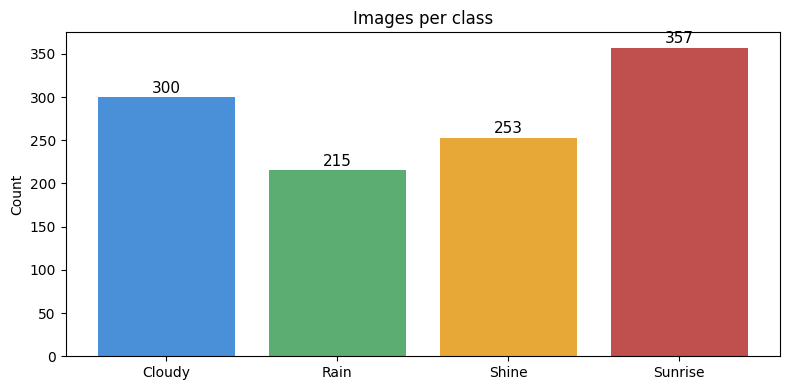

In [35]:
import os
import matplotlib.pyplot as plt

DATASET_DIR = '/content/drive/MyDrive/weather_classifier/dataset_raw/Multi-class Weather Dataset'

class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

counts = []
for cls in class_names:
    n = len(os.listdir(os.path.join(DATASET_DIR, cls)))
    counts.append(n)
    print(f"{cls}: {n} images")

print(f"\nTotal: {sum(counts)} images across {len(class_names)} classes")

plt.figure(figsize=(8, 4))
bars = plt.bar(class_names, counts, color=['#4A90D9', '#5BAD72', '#E8A838', '#C0504D'])
plt.title('Images per class')
plt.ylabel('Count')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [36]:
from PIL import Image
import os

DATASET_DIR = '/content/drive/MyDrive/weather_classifier/dataset_raw/Multi-class Weather Dataset'

corrupted = []
for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
        except Exception as e:
            corrupted.append(fpath)
            print(f"Corrupted: {fpath} — {e}")

if not corrupted:
    print("All images are clean — no corrupted files found.")
else:
    print(f"\n{len(corrupted)} corrupted files found.")

All images are clean — no corrupted files found.


In [37]:
import os
import shutil
import random

SRC_DIR = '/content/drive/MyDrive/weather_classifier/dataset_raw/Multi-class Weather Dataset'
SPLIT_DIR = '/content/drive/MyDrive/weather_classifier/dataset_split'

random.seed(42)

for cls in class_names:
    src_cls = os.path.join(SRC_DIR, cls)
    images = [f for f in os.listdir(src_cls) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    split = int(0.8 * len(images))
    train_imgs = images[:split]
    val_imgs = images[split:]

    for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs)]:
        out_dir = os.path.join(SPLIT_DIR, split_name, cls)
        os.makedirs(out_dir, exist_ok=True)
        for fname in split_imgs:
            shutil.copy(os.path.join(src_cls, fname), os.path.join(out_dir, fname))

    print(f"{cls}: {len(train_imgs)} train | {len(val_imgs)} val")

print(f"\nSplit saved to: {SPLIT_DIR}")

Cloudy: 240 train | 60 val
Rain: 172 train | 43 val
Shine: 202 train | 51 val
Sunrise: 285 train | 72 val

Split saved to: /content/drive/MyDrive/weather_classifier/dataset_split


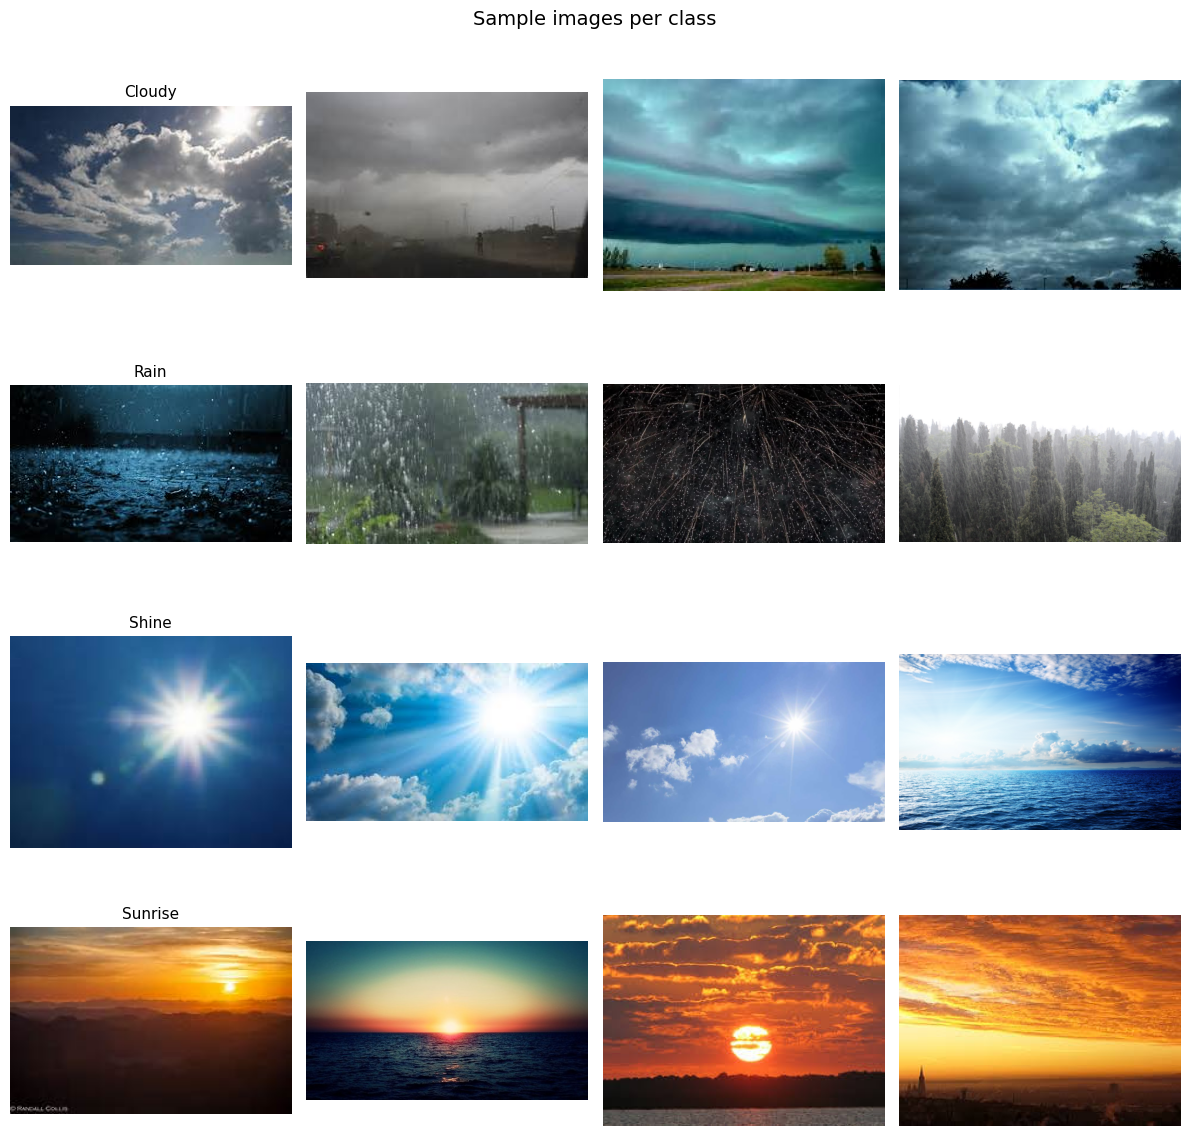

In [38]:
import matplotlib.pyplot as plt
from PIL import Image
import os

SPLIT_DIR = '/content/drive/MyDrive/weather_classifier/dataset_split'

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample images per class', fontsize=14)

for row, cls in enumerate(class_names):
    cls_path = os.path.join(SPLIT_DIR, 'train', cls)
    samples = os.listdir(cls_path)[:4]
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_path, fname))
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls if col == 0 else '', fontsize=11)
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

In [39]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SPLIT_DIR = '/content/drive/MyDrive/weather_classifier/dataset_split'
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, 'train'),
    transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, 'val'),
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Classes: ['Cloudy', 'Rain', 'Shine', 'Sunrise']
Train: 1020 images | Val: 347 images
Train batches: 32 | Val batches: 11


In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU topilmadi! Runtime > Change runtime type > T4 GPU ni tanlang.")

Using device: cuda
GPU: Tesla T4


In [41]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

# Backbone'ni freeze qilish
for param in model.parameters():
    param.requires_grad = False

# Oxirgi layerni almashtirish
model.fc = nn.Linear(512, len(class_names))

model = model.to(device)

print(f"Model: ResNet18 (transfer learning)")
print(f"Output classes: {len(class_names)} — {class_names}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model: ResNet18 (transfer learning)
Output classes: 4 — ['Cloudy', 'Rain', 'Shine', 'Sunrise']
Trainable params: 2,052


In [42]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Loss: CrossEntropyLoss")
print("Optimizer: Adam (lr=0.001)")
print("Scheduler: StepLR (step=5, gamma=0.5)")

Loss: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: StepLR (step=5, gamma=0.5)


In [43]:
from PIL import Image
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SPLIT_DIR = '/content/drive/MyDrive/weather_classifier/dataset_split'

# 1. Barcha corrupted fayllarni o'chirish
removed = []
for split in ['train', 'val']:
    for cls in os.listdir(os.path.join(SPLIT_DIR, split)):
        cls_path = os.path.join(SPLIT_DIR, split, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath)
                img.load()  # verify() emas, load() ishlatamiz
                img.close()
            except Exception as e:
                os.remove(fpath)
                removed.append(fpath)
                print(f"O'chirildi: {fpath}")

print(f"Jami o'chirildi: {len(removed)} fayl")

# 2. DataLoader qayta yaratish
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'val'),   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Classes: {class_names}")
print("DataLoader tayyor — training boshlasa bo'ladi!")

Jami o'chirildi: 0 fayl
Train: 1020 | Val: 347
Classes: ['Cloudy', 'Rain', 'Shine', 'Sunrise']
DataLoader tayyor — training boshlasa bo'ladi!


In [44]:
NUM_EPOCHS = 15

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # --- Val ---
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    # --- Metrics ---
    t_loss = train_loss / len(train_dataset)
    v_loss = val_loss / len(val_dataset)
    t_acc  = train_correct / len(train_dataset) * 100
    v_acc  = val_correct / len(val_dataset) * 100

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Best model saqlash
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/weather_classifier/best_model.pth')
        saved = "saved"
    else:
        saved = ""

    scheduler.step()

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
          f"Train Loss: {t_loss:.4f} Acc: {t_acc:.1f}% | "
          f"Val Loss: {v_loss:.4f} Acc: {v_acc:.1f}% {saved}")

print(f"\nBest Val Accuracy: {best_val_acc:.1f}%")

Epoch [ 1/15] Train Loss: 0.9987 Acc: 65.5% | Val Loss: 0.5735 Acc: 89.0% saved
Epoch [ 2/15] Train Loss: 0.5470 Acc: 87.7% | Val Loss: 0.3320 Acc: 94.5% saved
Epoch [ 3/15] Train Loss: 0.4078 Acc: 90.4% | Val Loss: 0.2646 Acc: 96.0% saved
Epoch [ 4/15] Train Loss: 0.3661 Acc: 90.3% | Val Loss: 0.2440 Acc: 94.2% 
Epoch [ 5/15] Train Loss: 0.3352 Acc: 90.5% | Val Loss: 0.1915 Acc: 95.7% 
Epoch [ 6/15] Train Loss: 0.2934 Acc: 90.9% | Val Loss: 0.1705 Acc: 97.4% saved
Epoch [ 7/15] Train Loss: 0.2682 Acc: 93.1% | Val Loss: 0.1758 Acc: 96.8% 
Epoch [ 8/15] Train Loss: 0.2620 Acc: 92.9% | Val Loss: 0.1509 Acc: 97.7% saved
Epoch [ 9/15] Train Loss: 0.2440 Acc: 93.5% | Val Loss: 0.1431 Acc: 97.7% 
Epoch [10/15] Train Loss: 0.2501 Acc: 93.3% | Val Loss: 0.1412 Acc: 98.0% saved
Epoch [11/15] Train Loss: 0.2357 Acc: 92.9% | Val Loss: 0.1414 Acc: 97.7% 
Epoch [12/15] Train Loss: 0.2370 Acc: 93.1% | Val Loss: 0.1424 Acc: 97.4% 
Epoch [13/15] Train Loss: 0.2387 Acc: 93.0% | Val Loss: 0.1425 Acc: 96

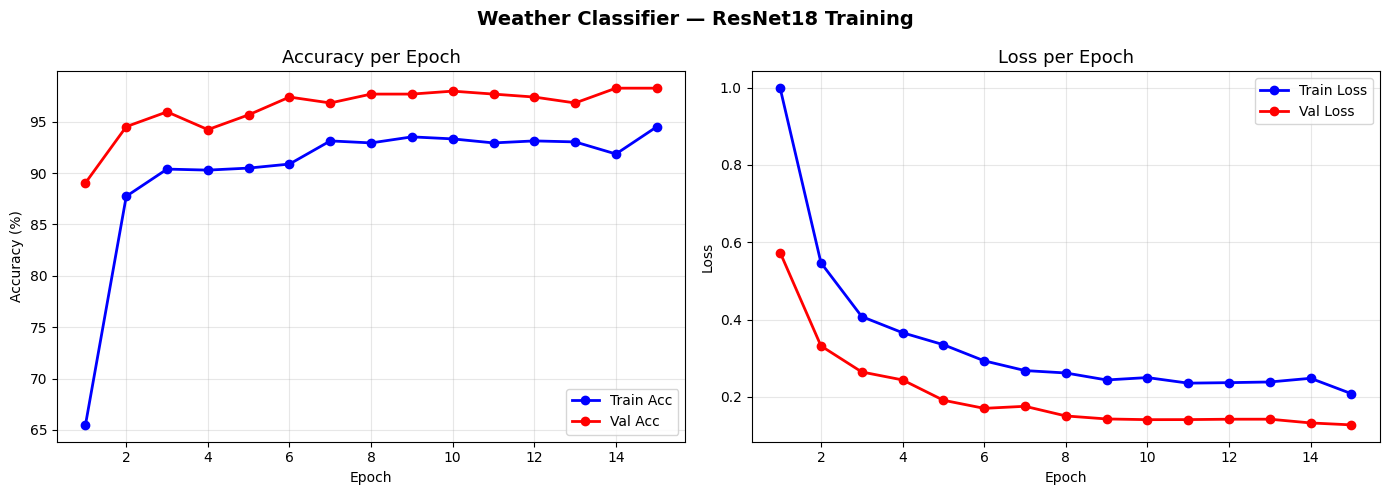

Grafik Drive'ga saqlandi.


In [45]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
ax1.plot(epochs, history['val_acc'],   'r-o', label='Val Acc',   linewidth=2)
ax1.set_title('Accuracy per Epoch', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
ax2.set_title('Loss per Epoch', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Weather Classifier — ResNet18 Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/weather_classifier/training_curves.png', dpi=150)
plt.show()
print("Grafik Drive'ga saqlandi.")

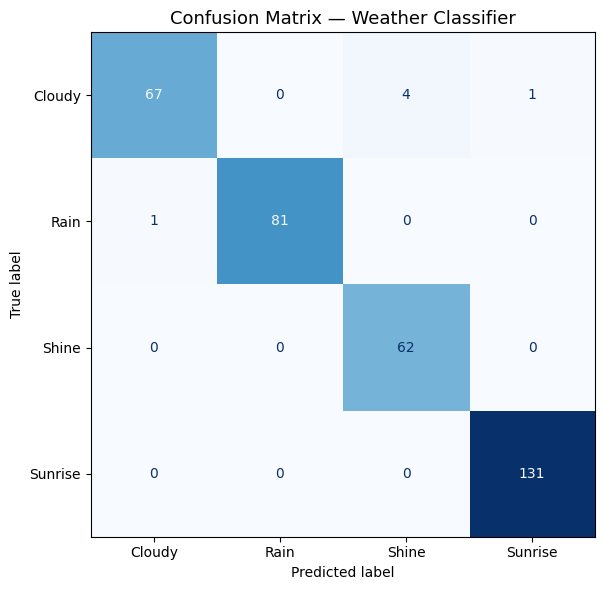


Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.99      0.93      0.96        72
        Rain       1.00      0.99      0.99        82
       Shine       0.94      1.00      0.97        62
     Sunrise       0.99      1.00      1.00       131

    accuracy                           0.98       347
   macro avg       0.98      0.98      0.98       347
weighted avg       0.98      0.98      0.98       347



In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Best model yuklab olish
model.load_state_dict(torch.load('/content/drive/MyDrive/weather_classifier/best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Weather Classifier', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/weather_classifier/confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Rasmingizni yuklang (jpg/png):


Saving cloudy.jpg to cloudy (1).jpg


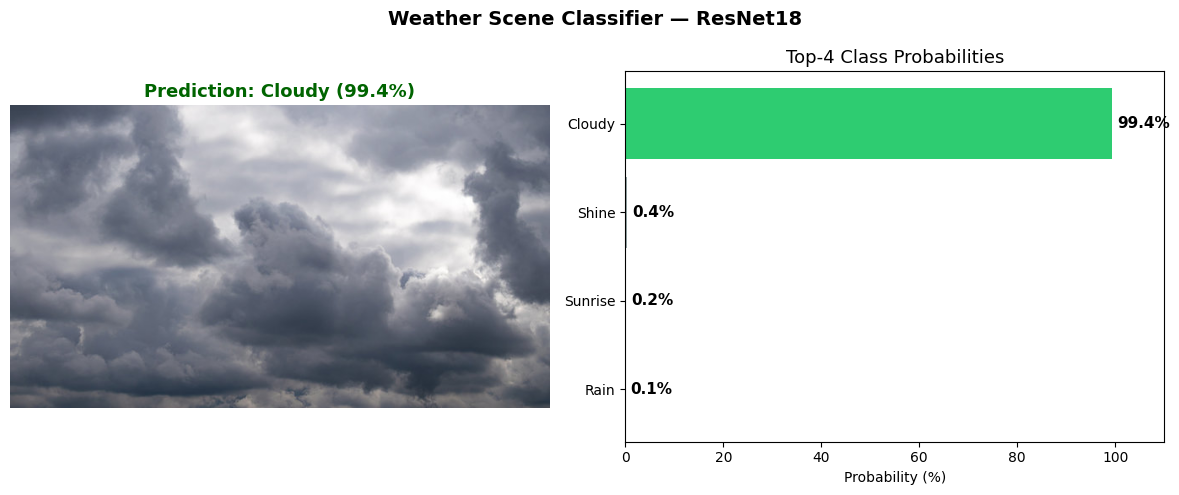


Top-4 Predictions:
  Cloudy      99.4% ███████████████████
  Shine        0.4% 
  Sunrise      0.2% 
  Rain         0.1% 


In [47]:
import torch
import torch.nn.functional as F
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Best modelni yuklash
model.load_state_dict(torch.load('/content/drive/MyDrive/weather_classifier/best_model.pth'))
model.eval()

# Rasm yuklash
print("Rasmingizni yuklang (jpg/png):")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Rasmni ochish va transform qilish
img = Image.open(img_path).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

input_tensor = preprocess(img).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    output = model(input_tensor)
    probs  = F.softmax(output, dim=1)[0]

top5_probs, top5_idxs = torch.topk(probs, k=4)
top5_probs = top5_probs.cpu().numpy() * 100
top5_idxs  = top5_idxs.cpu().numpy()
top5_labels = [class_names[i] for i in top5_idxs]

# Vizualizatsiya
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Rasm
ax1.imshow(img)
ax1.set_title(f"Prediction: {top5_labels[0]} ({top5_probs[0]:.1f}%)",
              fontsize=13, fontweight='bold', color='darkgreen')
ax1.axis('off')

# Bar chart
colors = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(4)]
bars = ax2.barh(top5_labels[::-1], top5_probs[::-1], color=colors[::-1])
ax2.set_xlabel('Probability (%)')
ax2.set_title('Top-4 Class Probabilities', fontsize=13)
ax2.set_xlim(0, 110)
for bar, prob in zip(bars, top5_probs[::-1]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{prob:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Weather Scene Classifier — ResNet18', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/weather_classifier/prediction_result.png', dpi=150)
plt.show()

print(f"\nTop-4 Predictions:")
for label, prob in zip(top5_labels, top5_probs):
    bar = '█' * int(prob / 5)
    print(f"  {label:<10} {prob:5.1f}% {bar}")

In [48]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'val_accuracy': 98.0
}, '/content/drive/MyDrive/weather_classifier/weather_model_final.pth')

print("Model saqlandi!")
print(f"Joylashuv: /content/drive/MyDrive/weather_classifier/weather_model_final.pth")
print(f"Classes: {class_names}")
print(f"Best Val Accuracy: 98.0%")
print("\nLoyiha tugadi!")

Model saqlandi!
Joylashuv: /content/drive/MyDrive/weather_classifier/weather_model_final.pth
Classes: ['Cloudy', 'Rain', 'Shine', 'Sunrise']
Best Val Accuracy: 98.0%

Loyiha tugadi!
